# Public Speaking dimension — end-to-end demo (Module 9)

**Runs on Google Colab GPU only** (Runtime → Change runtime type → **T4 GPU**).
Drive it from VS Code via the Google Colab extension, then **Run all**.

| Real (this notebook computes it) | Stubbed (owned by another module) |
|---|---|
| eye_contact, posture (YOLOv8-pose) | slide_structure → Module 4 |
| speech_pace, voice_stability (Librosa) | audience_engagement → Module 8 |
| opening_closing_impact (Qwen2.5-3B LLM) | |

No API keys — all intelligence is local/open-weight.


In [56]:
# ── ENVIRONMENT DETECTION + GPU CHECK ──────────────────────────────────────
import subprocess, sys, os

IS_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')

if IS_COLAB:
    result = subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total,memory.free",
                             "--format=csv,noheader"], capture_output=True, text=True)
    if result.returncode != 0:
        print("\u274c  NO GPU detected.")
        print("    Fix: Runtime \u2192 Change runtime type \u2192 T4 GPU \u2192 Save \u2192 Reconnect")
        raise SystemExit("No GPU \u2014 stopping to prevent slow CPU run.")
    print("\u2705  GPU detected:")
    for line in result.stdout.strip().split("\n"):
        name, total, free = [x.strip() for x in line.split(",")]
        print(f"    {name}  |  Total: {total}  |  Free: {free}")
    import importlib
    if importlib.util.find_spec("torch"):
        import torch
        if torch.cuda.is_available():
            print(f"    torch CUDA: {torch.cuda.get_device_name(0)}")
        else:
            print("    \u26a0\ufe0f  torch installed but CUDA not available")
    else:
        print("    (torch not yet installed \u2014 will be installed in Step 1)")
else:
    print("\U0001f5a5\ufe0f  Local Mac \u2014 GPU cells skipped; synthetic data used for Steps 1-4.")
    print("    Steps 5-10 (pure Python) run end-to-end.")


✅  GPU detected:
    Tesla T4  |  Total: 15360 MiB  |  Free: 944 MiB
    torch CUDA: Tesla T4


In [ ]:
# ── PROJECT SETUP (auto-update + auto-reload, no restart needed) ─────────────
# Colab pulls the latest code from GitHub AND purges any stale cached modules,
# so a `git push` from your Mac + Run All is all it takes — no runtime restart.
#
# ONE-TIME Colab setup for the PRIVATE repo:
#   1. GitHub → Settings → Developer settings → Fine-grained tokens →
#      read-only token for `personalised-lms-service` (Contents: Read).
#   2. Colab → 🔑 key icon → add secret GITHUB_TOKEN, enable "Notebook access".
#   (Public repo? The token step is unnecessary.)

import os, sys, subprocess

IS_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')
REPO = "github.com/hanvith6/personalised-lms-service"

if IS_COLAB:
    PROJECT_PATH = '/content/personalised-lms-service'

    if os.path.exists(os.path.join(PROJECT_PATH, '.git')):
        subprocess.run(["git", "-C", PROJECT_PATH, "pull", "--quiet"], check=False)
        print("\u2705  git pull \u2014 repo updated to latest")
    else:
        url = f"https://{REPO}"
        try:
            from google.colab import userdata
            _tok = userdata.get("GITHUB_TOKEN")
            if _tok:
                url = f"https://{_tok}@{REPO}"
        except Exception:
            pass
        subprocess.run(["git", "clone", "--quiet", url, PROJECT_PATH], check=True)
        print("\u2705  git clone \u2014 repo fetched")
else:
    PROJECT_PATH = '/Users/hanvith/dev/Quant/personalised-lms-service'

if not os.path.exists(os.path.join(PROJECT_PATH, 'utils', 'taxonomy.py')):
    raise FileNotFoundError(
        f"Project not found at {PROJECT_PATH}\n"
        "Colab: check the GITHUB_TOKEN secret (\U0001f511 icon) and repo name.\n"
        "Local: verify PROJECT_PATH."
    )

sys.path.insert(0, PROJECT_PATH)
os.chdir(PROJECT_PATH)

# ── AUTO-RELOAD: drop stale cached modules so later cells import fresh code ───
# Without this, a warm kernel keeps the OLD module after a pull (the classic
# "I pulled but it still runs old code" trap). Purging forces re-import on next
# `from services... import ...`, so Run All picks up new code WITHOUT a restart.
_PKGS = {"utils", "services", "dimensions", "api"}
for _name in [m for m in sys.modules if m.split(".")[0] in _PKGS]:
    del sys.modules[_name]
print("\u267b\ufe0f  cleared cached project modules \u2014 fresh code will load")

print(f"\u2705  Loaded: {PROJECT_PATH}")
print(f"    IS_COLAB={IS_COLAB}  |  Files: {os.listdir(PROJECT_PATH)}")


In [58]:
# ── RUN MODE ─────────────────────────────────────────────────────────────────
# LOCAL_DEBUG = True   → synthetic data, no heavy installs, runs in ~5s anywhere
# LOCAL_DEBUG = False  → full pipeline (real video + YOLO + Whisper + Qwen2.5-3B)
#
# On local Mac : always True (IS_COLAB=False forces synthetic)
# On Colab     : set False for real scores, True for fast debug

LOCAL_DEBUG = not IS_COLAB   # auto: Mac=True, Colab=False
# LOCAL_DEBUG = True         # \u2190 uncomment to force debug mode on Colab too

# ── STUDENT VIDEO ────────────────────────────────────────────────────────────
# YouTube URL (downloaded via yt-dlp) OR a direct .mp4/.webm URL.
# Leave "" to use the built-in sample clip / synthetic fallback.
# All defaults below are TEDx / TED-Ed / OER \u2014 CC-licensed, single presenter.

STUDENT_VIDEO_URL = "https://www.youtube.com/watch?v=rW2r5uStgG0"  # Luke Bakic \u2014 Power of Reading (3:10) \u2014 clean baseline

# Alternatives (swap the line above):
#   "https://www.youtube.com/watch?v=wbftlDzIALA"  # Georgia Haukom \u2014 Effects of Lying (3:11) \u2014 clear open/close
#   "https://www.youtube.com/watch?v=OMbNoo4mCcI"  # Cameron Allen \u2014 Education For All (3:21) \u2014 strong eye contact
#   "https://www.youtube.com/watch?v=Z0LhdQIhmzk"  # Gifted Labeling (5:22) \u2014 longer, persuasive
#   "https://www.youtube.com/watch?v=V8eLdbKXGzk"  # Good vs Bad Presentation (5:13) \u2014 A/B calibration stress test

print(f"RUN MODE: {'LOCAL_DEBUG (synthetic data)' if LOCAL_DEBUG else 'FULL PIPELINE (real video + models)'}")
if STUDENT_VIDEO_URL and not LOCAL_DEBUG:
    print(f"STUDENT_VIDEO_URL: {STUDENT_VIDEO_URL}")


RUN MODE: FULL PIPELINE (real video + models)
STUDENT_VIDEO_URL: https://www.youtube.com/watch?v=rW2r5uStgG0


## Step 1 — Install deps + load the local LLM

In [59]:
# ── STEP 1a: Install heavy deps (Colab full-pipeline only) ───────────────────
# Unpinned: let pip resolve against Colab's pre-installed torch / numpy / cuda.
# (Strict == pins fight Colab's base image and fail to resolve.)
# torch, numpy, requests, ffmpeg are already on Colab — only the extras here.
if not LOCAL_DEBUG:
    !pip install -q ultralytics openai-whisper librosa transformers accelerate soundfile
    print("\u2705  deps installed")
else:
    print("\u23ed\ufe0f  LOCAL_DEBUG: skipping heavy installs.")


✅  deps installed


In [60]:
# Make the project package importable.
# Walks up from cwd to find utils/taxonomy.py; falls back to known local path.
import os, sys

LOCAL_PATH = '/Users/hanvith/dev/Quant/personalised-lms-service'

def find_root(start):
    d = os.path.abspath(start)
    for _ in range(8):
        if os.path.exists(os.path.join(d, "utils", "taxonomy.py")):
            return d
        d = os.path.dirname(d)
    return None

ROOT = find_root(os.getcwd()) or find_root(LOCAL_PATH) or LOCAL_PATH

if not os.path.exists(os.path.join(ROOT, "utils", "taxonomy.py")):
    raise RuntimeError(
        f"Project root not found (tried cwd and {LOCAL_PATH}).\n"
        "Run the PROJECT SETUP cell above first."
    )
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)
print("project root:", ROOT)


project root: /content/personalised-lms-service


In [61]:
# ── STEP 1b: Load LLM ────────────────────────────────────────────────────────
if not LOCAL_DEBUG:
    import torch
    from transformers import AutoModelForCausalLM, AutoTokenizer

    MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"   # set to 1.5B if VRAM is tight
    tok = AutoTokenizer.from_pretrained(MODEL_ID)
    mdl = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype="auto", device_map="auto")

    def llm_generate(prompt: str) -> str:
        msgs = [{"role": "user", "content": prompt}]
        text = tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        inputs = tok(text, return_tensors="pt").to(mdl.device)
        out = mdl.generate(**inputs, max_new_tokens=512, do_sample=False)
        return tok.decode(out[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)

    print("LLM ready:", MODEL_ID)
else:
    import urllib.request, json as _json

    _SCORE_STUB = '{"score": 7.0, "justification": "local stub \u2014 Ollama not reachable"}'
    _PATH_STUB  = _json.dumps([{
        "title": "Eye Contact Fundamentals", "dimension": "public_speaking",
        "skill_addressed": "eye_contact", "resource_type": "video",
        "difficulty": "beginner", "estimated_minutes": 20,
        "reason": "Builds camera-presence baseline.", "prerequisite_step_index": None,
    }, {
        "title": "Confident Posture Practice", "dimension": "public_speaking",
        "skill_addressed": "posture", "resource_type": "exercise",
        "difficulty": "beginner", "estimated_minutes": 15,
        "reason": "Reinforces upright stance.", "prerequisite_step_index": 0,
    }])

    def llm_generate(prompt: str) -> str:
        try:
            body = _json.dumps({"model": "mistral", "prompt": prompt, "stream": False}).encode()
            req = urllib.request.Request(
                "http://localhost:11434/api/generate", data=body,
                headers={"Content-Type": "application/json"})
            with urllib.request.urlopen(req, timeout=30) as resp:
                return _json.loads(resp.read())["response"]
        except Exception:
            return _PATH_STUB if "JSON array" in prompt else _SCORE_STUB

    print("\U0001f5a5\ufe0f  LOCAL_DEBUG: stub LLM ready (Ollama/Mistral + JSON fallback).")


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

LLM ready: Qwen/Qwen2.5-3B-Instruct


## Step 2 — Get a clip → frames → YOLOv8-pose → eye_contact + posture

Tries a license-clean download; on **any** failure falls back to a synthetic clip
(and synthetic demo pose/transcript) so the notebook always runs end-to-end.

In [62]:
import os, subprocess, hashlib, glob

USED_SYNTHETIC = LOCAL_DEBUG
VIDEO = "sample_clip.mp4"
_MAX_BYTES = 200 * 1024 * 1024   # 200 MB cap

def _sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""): h.update(chunk)
    return h.hexdigest()

if not LOCAL_DEBUG:
    # ── Path 1: YouTube / arbitrary URL via yt-dlp ───────────────────────────
    if STUDENT_VIDEO_URL and ("youtube.com" in STUDENT_VIDEO_URL or "youtu.be" in STUDENT_VIDEO_URL):
        try:
            subprocess.run(["pip", "install", "-q", "yt-dlp"], check=True)
            VIDEO = "student_presentation.mp4"
            subprocess.run(["yt-dlp", "-f", "mp4[height<=480]/best[height<=480]",
                            "-o", VIDEO, STUDENT_VIDEO_URL], check=True)
            print("\u2705  downloaded via yt-dlp:", VIDEO)
        except Exception as e:
            print("yt-dlp failed (", e, ") -> synthetic fallback")
            USED_SYNTHETIC = True

    # ── Path 2: direct .mp4/.webm URL (Wikimedia needs a User-Agent) ─────────
    else:
        import requests
        DIRECT_URL = STUDENT_VIDEO_URL or (
            "https://upload.wikimedia.org/wikipedia/commons/transcoded/9/9b/"
            "Sample_speech.ogv/Sample_speech.ogv.360p.webm")
        VIDEO = "sample_clip" + (".webm" if DIRECT_URL.endswith(".webm") else ".mp4")
        # 403-fix: Wikimedia blocks requests without a real User-Agent.
        HEADERS = {"User-Agent": "Mozilla/5.0 (Quantum-LMS demo; contact bhimireddy.h@northeastern.edu)"}
        try:
            with requests.get(DIRECT_URL, headers=HEADERS, stream=True, timeout=(5, 30)) as r:
                r.raise_for_status()
                received = 0
                with open(VIDEO, "wb") as fh:
                    for chunk in r.iter_content(chunk_size=65536):
                        received += len(chunk)
                        if received > _MAX_BYTES:
                            raise ValueError(f"download exceeded {_MAX_BYTES // (1024**2)} MB cap")
                        fh.write(chunk)
            print("\u2705  downloaded:", VIDEO, "sha256:", _sha256(VIDEO)[:16], "...")
        except Exception as e:
            print("download failed (", e, ") -> synthetic fallback")
            USED_SYNTHETIC = True
else:
    print("\U0001f5a5\ufe0f  LOCAL_DEBUG: using synthetic clip.")

# ── Synthetic fallback: 6s test pattern + tone, fully offline ────────────────
if USED_SYNTHETIC:
    VIDEO = "sample_clip.mp4"
    subprocess.run(["ffmpeg", "-y", "-f", "lavfi", "-i", "testsrc=size=640x480:rate=2:duration=6",
                    "-f", "lavfi", "-i", "sine=frequency=220:duration=6", "-shortest",
                    VIDEO], check=True, capture_output=True)
    print("synthetic clip ready:", VIDEO)


✅  downloaded via yt-dlp: student_presentation.mp4


In [63]:
import os, glob
import numpy as np

COCO = ["nose","left_eye","right_eye","left_ear","right_ear","left_shoulder","right_shoulder",
        "left_elbow","right_elbow","left_wrist","right_wrist","left_hip","right_hip",
        "left_knee","right_knee","left_ankle","right_ankle"]

if not LOCAL_DEBUG:
    from ultralytics import YOLO
    os.makedirs("frames", exist_ok=True)
    for p in glob.glob("frames/*.jpg"): os.remove(p)
    subprocess.run(["ffmpeg", "-y", "-i", VIDEO, "-vf", "fps=2", "frames/f_%04d.jpg"],
                   check=True, capture_output=True)
    frame_paths = sorted(glob.glob("frames/*.jpg"))
    pose_model = YOLO("yolov8n-pose.pt")
    pose_frames = []
    for res in pose_model(frame_paths, verbose=False):
        if res.keypoints is None or res.keypoints.data.shape[0] == 0:
            pose_frames.append({"keypoints": {}})
            continue
        kp = res.keypoints.data[0].cpu().numpy()
        pose_frames.append({"keypoints": {COCO[i]: (float(kp[i,0]), float(kp[i,1]), float(kp[i,2]))
                                          for i in range(len(COCO))}})
    print(f"{len(pose_frames)} frames; persons detected in "
          f"{sum(1 for f in pose_frames if f['keypoints'])}")
else:
    print("\U0001f5a5\ufe0f  LOCAL_DEBUG: injecting synthetic pose data.")
    pose_frames = [{"keypoints": {
        "nose": (50, 30, 0.9), "left_eye": (40, 25, 0.9), "right_eye": (60, 25, 0.9),
        "left_shoulder": (38, 100, 0.9), "right_shoulder": (62, 104, 0.9),
        "left_hip": (42, 200, 0.9), "right_hip": (58, 200, 0.9)}}] * 6
    pose_frames[0] = {"keypoints": {"nose": (95, 30, 0.9), "left_eye": (40, 25, 0.9),
                                    "right_eye": (60, 25, 0.9)}}
    print(f"{len(pose_frames)} synthetic frames injected.")


379 frames; persons detected in 365


In [64]:
# Inject richer synthetic pose if still empty (no person in clip).
if not any(f["keypoints"] for f in pose_frames):
    print("NOTE: no keypoints detected \u2014 falling back to synthetic pose.")
    pose_frames = [{"keypoints": {
        "nose": (50, 30, 0.9), "left_eye": (40, 25, 0.9), "right_eye": (60, 25, 0.9),
        "left_shoulder": (38, 100, 0.9), "right_shoulder": (62, 104, 0.9),
        "left_hip": (42, 200, 0.9), "right_hip": (58, 200, 0.9)}}] * 6
    pose_frames[0] = {"keypoints": {"nose": (95, 30, 0.9), "left_eye": (40, 25, 0.9),
                                    "right_eye": (60, 25, 0.9)}}

from dimensions.public_speaking.scorer_ps import score_eye_contact, score_posture
s_eye = score_eye_contact(pose_frames)
s_post = score_posture(pose_frames)
print(s_eye)
print(s_post)


SubSkillScore(skill='eye_contact', score=9.010989010989011, source=<ScoreSource.POSE: 'pose'>, detail={'frames': 379, 'frames_with_face': 364, 'facing_fraction': 0.901})
SubSkillScore(skill='posture', score=9.546186777392888, source=<ScoreSource.POSE: 'pose'>, detail={'frames_scored': 364})


## Step 3 — Audio → Librosa → speech_pace + voice_stability

In [65]:
import numpy as np

if not LOCAL_DEBUG:
    import librosa
    subprocess.run(["ffmpeg", "-y", "-i", VIDEO, "-ac", "1", "-ar", "16000", "audio.wav"],
                   check=True, capture_output=True)
    y, sr = librosa.load("audio.wav", sr=16000)
    duration_s = float(librosa.get_duration(y=y, sr=sr))
    f0, _, _ = librosa.pyin(y, fmin=80, fmax=400, sr=sr)
    f0 = np.nan_to_num(f0)
    rms = librosa.feature.rms(y=y)[0]
    print(f"duration={duration_s:.1f}s  voiced_frames={(f0>0).sum()}")
else:
    print("\U0001f5a5\ufe0f  LOCAL_DEBUG: injecting synthetic audio features.")
    sr = 16000
    duration_s = 30.0
    f0  = np.concatenate([np.zeros(50), np.linspace(130, 210, 100), np.zeros(50)])
    rms = np.ones(200) * 0.05
    y   = np.zeros(int(sr * duration_s))
    print(f"duration={duration_s:.1f}s  voiced_frames={(f0>0).sum()}")


duration=189.3s  voiced_frames=3196


In [66]:
_DEMO_TRANSCRIPT = (
    "Good morning everyone and thank you for being here today. "
    "I want to share three ideas that changed how I work. "
    "First, focus beats hustle. Second, feedback is a gift. "
    "Third, ship small and often. Remember this: progress compounds, "
    "so start today and let your future self thank you."
)

if not LOCAL_DEBUG:
    import whisper
    asr = whisper.load_model("base")
    transcript = asr.transcribe("audio.wav").get("text", "").strip()
    if len(transcript.split()) < 12:
        print("NOTE: short/empty transcript \u2014 using synthetic demo.")
        transcript = _DEMO_TRANSCRIPT
else:
    print("\U0001f5a5\ufe0f  LOCAL_DEBUG: using synthetic demo transcript.")
    transcript = _DEMO_TRANSCRIPT

word_count = len(transcript.split())

from dimensions.public_speaking.scorer_ps import score_speech_pace, score_voice_stability
s_pace = score_speech_pace(word_count, duration_s)
s_voice = score_voice_stability(f0, rms)
print(s_pace)
print(s_voice)


SubSkillScore(skill='speech_pace', score=8.834133568130015, source=<ScoreSource.AUDIO: 'audio'>, detail={'wpm': 150.2})
SubSkillScore(skill='voice_stability', score=3.678698344474922, source=<ScoreSource.AUDIO: 'audio'>, detail={'cv': 0.632})


## Step 4 — Whisper transcript → LLM → opening_closing_impact

In [67]:
from dimensions.public_speaking.scorer_ps import score_opening_closing
s_open = score_opening_closing(transcript, llm_generate)
print(s_open)
print("justification:", s_open.detail.get("justification"))

LLMOutputError: failed to parse valid JSON after 3 attempts: missing 'score'

## Step 5 — Stubbed sub-skills (owned by Modules 4 & 8) — clearly MOCK

In [ ]:
from dimensions.public_speaking.stubs.module4_stub import stub_slide_structure
from dimensions.public_speaking.stubs.module8_stub import stub_audience_engagement

STUDENT_ID = "stu-2026-001"
s_slide = stub_slide_structure(STUDENT_ID)
s_aud = stub_audience_engagement(STUDENT_ID)
print("MOCK", s_slide)
print("MOCK", s_aud)

all_scores = [s_eye, s_post, s_pace, s_voice, s_open, s_slide, s_aud]
for s in all_scores:
    print(f"  {s.skill:24s} {s.score:5.2f}  [{s.source.value}]")

MOCK SubSkillScore(skill='slide_structure', score=8.62, source=<ScoreSource.STUB: 'stub'>, detail={'mock': True, 'owner': 'Module 4 (Auto-Video-Content)'})
MOCK SubSkillScore(skill='audience_engagement', score=9.27, source=<ScoreSource.STUB: 'stub'>, detail={'mock': True, 'owner': 'Module 8 (Community & Group Discussion)'})
  eye_contact               8.33  [pose]
  posture                   9.17  [pose]
  speech_pace               0.00  [audio]
  voice_stability           9.85  [audio]
  opening_closing_impact    8.00  [llm]
  slide_structure           8.62  [stub]
  audience_engagement       9.27  [stub]


In [ ]:
# ── SCORE MATRIX — all 7 sub-skills ──────────────────────────────────────────
def _band(score):
    if score >= 8: return "STRONG"
    if score >= 6: return "OK"
    if score >= 4: return "WEAK"
    return "CRITICAL"

print(f"\n{'Sub-Skill':<28} {'Score':>6}  {'Band':<10}  Source")
print("\u2500" * 58)
for s in all_scores:
    print(f"  {s.skill:<26} {s.score:>5.2f}  {_band(s.score):<10}  {s.source.value}")
avg = sum(s.score for s in all_scores) / len(all_scores)
print("\u2500" * 58)
print(f"  {'AVERAGE':<26} {avg:>5.2f}")



Sub-Skill                     Score  Band        Source
──────────────────────────────────────────────────────────
  eye_contact                 8.33  STRONG      pose
  posture                     9.17  STRONG      pose
  speech_pace                 0.00  CRITICAL    audio
  voice_stability             9.85  STRONG      audio
  opening_closing_impact      8.00  STRONG      llm
  slide_structure             8.62  STRONG      stub
  audience_engagement         9.27  STRONG      stub
──────────────────────────────────────────────────────────
  AVERAGE                     7.61


## Step 6 — Gap detection over the 7 scores

In [ ]:
from services.gap_detector import detect_gaps
from dimensions.public_speaking.taxonomy_ps import DEMAND_BOOSTS

gaps = detect_gaps(all_scores, DEMAND_BOOSTS)
for g in gaps:
    print(f"  {g.skill:24s} score={g.score:.2f} severity={g.gap_severity:.2f} "
          f"priority={g.priority_score:.2f}")
top5 = gaps[:5]

  speech_pace              score=0.00 severity=6.00 priority=8.70


## Step 7 — Generate an adaptive learning path (LLM)

In [ ]:
from services.path_generator import generate_learning_path

path = generate_learning_path(
    target_role="Data Analyst",
    top_gaps=top5,
    avg_completion_hours=4,
    pace="moderate",
    preferred_resource_types=["video", "exercise", "article"],
    llm_generate=llm_generate,
)
print(f"{len(path)} steps generated")

3 steps generated


## Step 8 — Print the path + gap-severity chart (dashboard stand-in)

In [ ]:
for i, step in enumerate(path):
    pre = step["prerequisite_step_index"]
    print(f"{i}. [{step['difficulty']}] {step['title']} ({step['resource_type']}, "
          f"{step['estimated_minutes']}m) -> {step['skill_addressed']}"
          + (f"  (after step {pre})" if pre is not None else ""))
    print(f"     reason: {step['reason']}")

0. [beginner] Speech Pacing Basics (article, 30m) -> speech_pace
     reason: This article will help learners understand the basics of speech pacing and why it's important for effective communication.
1. [intermediate] Practice Speech Pacing Exercises (exercise, 60m) -> speech_pace  (after step 0)
     reason: Learners can apply what they've learned from the article through practical exercises to improve their speech pacing.
2. [advanced] Advanced Speech Pacing Techniques (video, 60m) -> speech_pace  (after step 1)
     reason: This video will cover advanced techniques to enhance speech pacing skills.


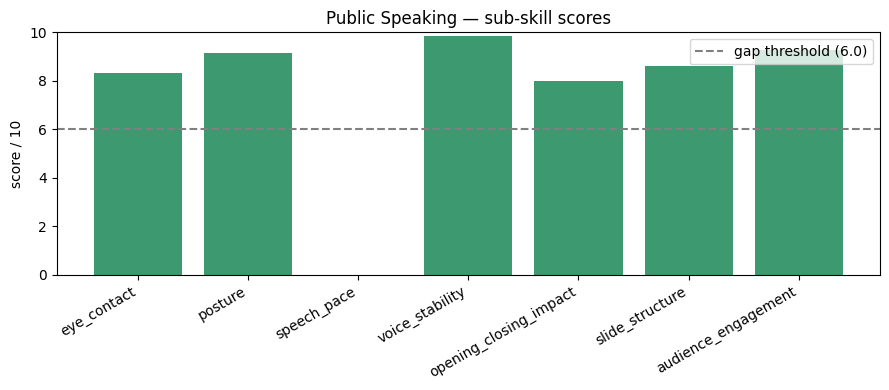

In [ ]:
import matplotlib.pyplot as plt

def band_color(score):
    return "#d64545" if score < 4 else ("#e0a82e" if score < 6 else "#3d9970")  # red/amber/green

labels = [s.skill for s in all_scores]
vals = [s.score for s in all_scores]
colors = [band_color(v) for v in vals]

plt.figure(figsize=(9, 4))
plt.bar(labels, vals, color=colors)
plt.axhline(6.0, ls="--", c="grey", label="gap threshold (6.0)")
plt.ylim(0, 10); plt.ylabel("score / 10"); plt.xticks(rotation=30, ha="right")
plt.title("Public Speaking — sub-skill scores"); plt.legend(); plt.tight_layout()
plt.show()

## Step 9 — Adaptive sequencing demo

Rule: a step completed at **>85%** accelerates the next step's difficulty; a skill
scoring **<50% twice** gets a simpler prerequisite inserted. Uses fake completion events.

In [ ]:
from services.path_generator import adapt_path

fake_events = [
    {"step_index": 0, "skill": path[0]["skill_addressed"], "score_pct": 92},   # accelerate next
    {"skill": top5[0].skill, "score_pct": 40},                                  # struggle 1
    {"skill": top5[0].skill, "score_pct": 47},                                  # struggle 2 -> prereq
]
adapted = adapt_path(path, fake_events)
print(f"original {len(path)} steps -> adapted {len(adapted)} steps")
for i, step in enumerate(adapted):
    print(f"{i}. [{step['difficulty']}] {step['title']} -> {step['skill_addressed']}")

original 3 steps -> adapted 4 steps
0. [beginner] Prerequisite primer: speech_pace -> speech_pace
1. [beginner] Speech Pacing Basics -> speech_pace
2. [advanced] Practice Speech Pacing Exercises -> speech_pace
3. [advanced] Advanced Speech Pacing Techniques -> speech_pace


## Step 10 — Emit the gap profile to the shared analytics module (Module 5)

In [ ]:
from services.analytics_emit import emit_gap_profile_updated
payload = emit_gap_profile_updated(STUDENT_ID, gaps)
print("\nemitted event:", payload["event"], "for", payload["student_id"])

[analytics -> Module 5] {"event": "gap_profile_updated", "student_id": "stu-2026-001", "gaps": [{"skill": "speech_pace", "score": 0.0, "gap_severity": 6.0, "priority_score": 8.7, "dimension": "public_speaking"}]}

emitted event: gap_profile_updated for stu-2026-001


## Step 11 — Multi-video score comparison

Each run appends its 7-score vector (keyed by video) to a JSON file that survives
**Run All**. Swap `STUDENT_VIDEO_URL` in the RUN MODE cell, Run All again, and a new
column appears. Ideal for the #5 *Good vs Bad Presentation* A/B calibration test.


In [ ]:
# ── MULTI-VIDEO SCORE COMPARISON (persists across Run All) ───────────────────
import json, os

COMPARE_FILE = os.path.join(PROJECT_PATH, "score_comparison.json")

def _video_label():
    if LOCAL_DEBUG or not STUDENT_VIDEO_URL:
        return "synthetic"
    url = STUDENT_VIDEO_URL
    if "v=" in url:
        return url.split("v=")[-1][:11]
    return url.rstrip("/").split("/")[-1][:11]

label = _video_label()

# Load prior runs, record this one, save.
store = {}
if os.path.exists(COMPARE_FILE):
    with open(COMPARE_FILE) as f:
        store = json.load(f)

store[label] = {s.skill: round(s.score, 2) for s in all_scores}
store[label]["AVERAGE"] = round(sum(s.score for s in all_scores) / len(all_scores), 2)

with open(COMPARE_FILE, "w") as f:
    json.dump(store, f, indent=2)

# ── Side-by-side table: rows = sub-skills, columns = videos ──────────────────
skills = [s.skill for s in all_scores] + ["AVERAGE"]
videos = list(store.keys())
col_w = max(12, max((len(v) for v in videos), default=12) + 2)

header = f"{'sub-skill':<26}" + "".join(f"{v:>{col_w}}" for v in videos)
print(header)
print("\u2500" * len(header))
for sk in skills:
    sep = "\u2500" * len(header) if sk == "AVERAGE" else None
    if sep: print(sep)
    row = f"{sk:<26}"
    for v in videos:
        val = store[v].get(sk)
        row += f"{val:>{col_w}.2f}" if isinstance(val, (int, float)) else f"{'':>{col_w}}"
    print(row)

# ── A/B delta when exactly two videos recorded ───────────────────────────────
if len(videos) == 2:
    a, b = videos
    print(f"\n\u0394 ({b} \u2212 {a}):")
    for sk in skills:
        va, vb = store[a].get(sk), store[b].get(sk)
        if isinstance(va, (int, float)) and isinstance(vb, (int, float)):
            d = vb - va
            arrow = "\u2191" if d > 0 else ("\u2193" if d < 0 else "=")
            print(f"  {sk:<24} {d:+6.2f} {arrow}")

print(f"\n{len(videos)} run(s) in {COMPARE_FILE}")
print("Swap STUDENT_VIDEO_URL + Run All to add a column. Delete the file to reset.")


## Step 12 — Serve the dimension over HTTP (thin FastAPI wrapper)

The same scores can be driven through the live REST API (`api/main.py`). Here we
use FastAPI's in-process `TestClient` so it runs on Colab with no port/server —
the exact same request/response path a real `uvicorn` server would handle.
Demonstrates **AC-09** over HTTP: scores \u2192 gaps \u2192 path \u2192 completion event \u2192 adapted path.

> To run it as a real server instead:
> `pip install -r requirements-api.txt && uvicorn api.main:app --port 8400`
> then open http://localhost:8400 for the **My Learning Path** widget.


In [ ]:
# ── HTTP loop demo via in-process TestClient (works on Colab, no server) ─────
try:
    from fastapi.testclient import TestClient
    from api.main import app
    from api import store as _api_store

    _api_store.reset()
    cli = TestClient(app)
    SID = STUDENT_ID  # from Step 5

    # Real scores computed earlier -> JSON payload for POST /scores
    payload = {"scores": [
        {"skill": s.skill, "score": float(s.score), "source": s.source.value}
        for s in all_scores
    ]}

    print("POST /scores/" + SID)
    r = cli.post(f"/scores/{SID}", json=payload)
    gaps = r.json()["gaps"]
    print(f"  -> {len(gaps)} gap(s):", [g["skill"] for g in gaps])

    print("POST /path/generate/" + SID)
    r = cli.post(f"/path/generate/{SID}", json={"target_role": "Data Analyst", "pace": "moderate"})
    steps = r.json()["steps"]
    print(f"  -> {len(steps)} step(s); daily focus: '{steps[0]['title']}'")

    print("POST /path/event/" + SID, "(complete step 0 @ 92%)")
    ev = {"events": [{"step_index": 0, "skill": steps[0]["skill_addressed"], "score_pct": 92}]}
    r = cli.post(f"/path/event/{SID}", json=ev)
    print(f"  -> adapted to {len(r.json()['steps'])} step(s); progress {r.json()['progress_pct']}%")

    print("GET /gaps/" + SID + "/summary")
    print("  ->", cli.get(f"/gaps/{SID}/summary").json())

    print("\n\u2705  HTTP loop OK \u2014 the dimension is live-serviceable (AC-09 over REST).")
except ModuleNotFoundError as e:
    print("\u23ed\ufe0f  Skipping HTTP demo \u2014 install fastapi: pip install fastapi httpx")
    print("    (", e, ")")
